In [1]:
import time
import numpy as np
from examples.seismic import SeismicModel, AcquisitionGeometry, Receiver
from examples.seismic.acoustic import AcousticWaveSolver
from examples.seismic.datasets import SeismogramDataset, VelocityModel
from devito import info, TimeFunction, Function, Eq, Operator, norm, inner
from examples.seismic.utils import taper_wavelet, estimate_centroid_frequency_gather
from devito import configuration
from matplotlib import pyplot as plt


PATH_MODEL = "../data/South_ForMigr_2.dat"
PATH_DATA = "../data/21-20.sgy"
NBL=500
SO=4
TMAX = 40.0

configuration["platform"] = "nvidiaX"
configuration["language"] = "openacc"
configuration["compiler"] = "nvc"

def setup_model_and_geometry(iter_num):
    """Set up the velocity model and acquisition geometry"""
    dataset = SeismogramDataset(PATH_DATA, "sou", invert_elevs=True)
    xmin, xmax = min(dataset.x_coords.min(), dataset.opposite_x.min()), max(dataset.x_coords.max(), dataset.opposite_x.max())
    spacing = (0.025, 0.025)
    velmodel = VelocityModel(
        PATH_MODEL,
        dx=spacing[0],
        dz=spacing[1],
        clip=True,
        xmin=xmin - 3,
        xmax=xmax + 3,
        zmin=-318,
    )
    velmodel.pad_left(4 + 2)
    velmodel.pad_right(8 * int(0.5 / spacing[0]) + 2)
    velmodel.pad_bottom(10 * int(0.5 / spacing[0]) + 2)
    velmodel.pad_top(7 * int(0.5 / spacing[0]))

    vp = velmodel.vp.T
    origin = velmodel.x[0], velmodel.z[0]
    model = SeismicModel(
        vp=vp,
        origin=origin,
        shape=vp.shape,
        spacing=spacing,
        space_order=SO,
        nbl=NBL,
        bcs="damp",
        fs=False,
    )
    return model, dataset

In [2]:
model, dataset = setup_model_and_geometry(0)
dataset._dt_r = model.critical_dt
dataset._t_max_r = TMAX
dataset.resample_on()

Operator `initdamp` ran in 0.20 s


In [3]:
print(model.critical_dt)

0.003084


In [4]:
d_obs, sx, sz, rec_x, rec_z = dataset[20]

t0 = 0
tn = TMAX

src_pos = np.array([sx, sz])[None, :]
rec_pos = np.vstack([rec_x, rec_z]).T
geometry = AcquisitionGeometry(
    model, rec_pos, src_pos,
    t0, tn, f0=0.25, src_type='Ricker'
)
solver = AcousticWaveSolver(model, geometry, space_order=SO)
d_syn = Receiver(name='d_syn', grid=model.grid, time_range=geometry.time_axis,
                     coordinates=geometry.rec_positions)
solver.forward(vp=model.vp, save=False, rec=d_syn)
residual = Receiver(name='residual', grid=model.grid, time_range=geometry.time_axis,
                coordinates=geometry.rec_positions)
residual.data[:] = d_syn.data[:] - d_obs.T
srca, v, summary = solver.adjoint(vp=model.vp, rec=residual)

Operator `Forward` ran in 12.75 s
No source type defined, returning uninitialized (zero) source
No source type defined, returning uninitialized (zero) source
Operator `Adjoint` ran in 12.75 s


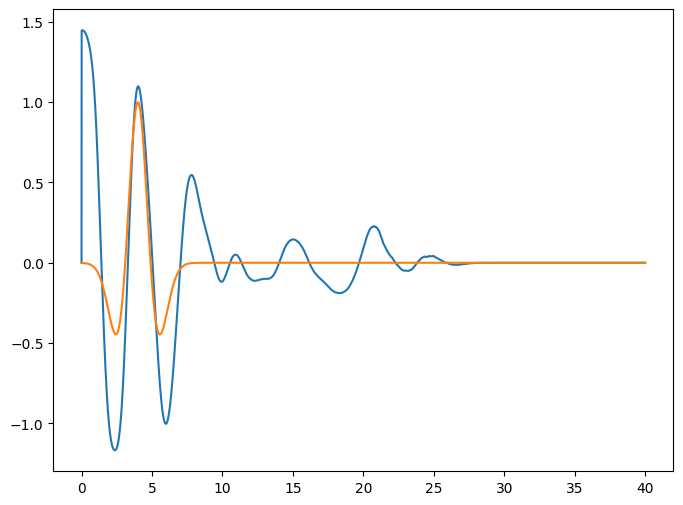

In [7]:
plt.plot(geometry.time_axis.time_values, srca.data[:]*1000)
plt.plot(geometry.time_axis.time_values, geometry.src.data[:])
plt.show()

In [8]:
def calculate_step_size(misfit, h):
    # Compute numerator and denominator for step size
    numerator = np.dot(misfit.reshape(-1), h.reshape(-1))
    denominator = np.dot(h.reshape(-1), h.reshape(-1))
    return numerator / denominator

from scipy.signal.windows import tukey

def left_taper_tukey(signal, alpha=0.5):
    """
    Taper the left side of a signal using a Tukey window.
    
    Args:
        signal (np.ndarray): Input signal (gradient).
        alpha (float): Shape parameter of the Tukey window (0=rectangular, 1=Hann).
    
    Returns:
        np.ndarray: Tapered signal.
    """
    n = len(signal)
    signal[0] = 0
    window = tukey(n * 2, alpha=alpha)[:n]  # Take left half of symmetric window
    return signal * window, window

Estimated gather centroid frequency: 380.67 Hz, Wavelet length: 2.63 ms


Operator `Forward` ran in 5.04 s
Operator `Adjoint` ran in 5.04 s


Scale:  242354.52685509226 2.9571327387333093 3.4652136236208952 45.40718646589179
Iter 0: Misfit = 1.3784e+05


Operator `Forward` ran in 4.74 s
Operator `Adjoint` ran in 4.73 s


Scale:  289568.69709211856 2.9571327387333093 2.7499388615937925 5.624954905385814
Iter 1: Misfit = 2.4247e+04


...

Scale:  402451.56584473647 2.9571327387333093 3.1059796265262714 28.15741213630032
Iter 2: Misfit = 1.8117e+04


Operator `Forward` ran in 4.65 s
Operator `Adjoint` ran in 4.78 s


Scale:  493613.67192982277 2.9571327387333093 3.1767270691745257 4.427487400509806
Iter 3: Misfit = 3.5047e+03


Operator `Forward` ran in 4.71 s
Operator `Adjoint` ran in 4.75 s


Scale:  650340.8860896304 2.9571327387333093 3.5064326971804127 13.94245050259349
Iter 4: Misfit = 2.5278e+03


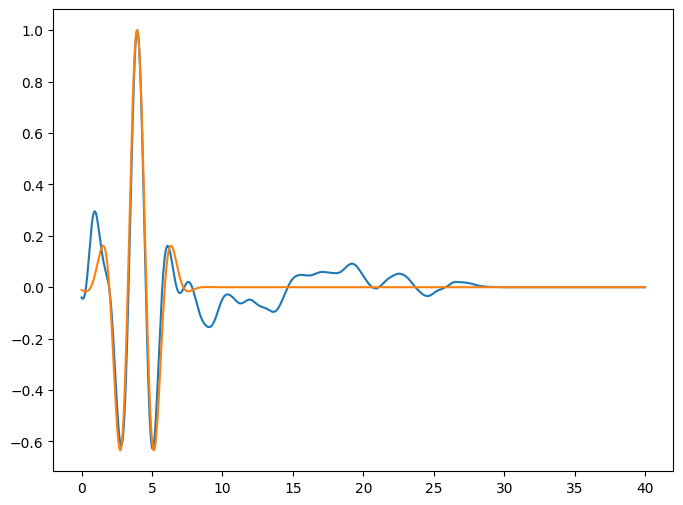

Estimated gather centroid frequency: 405.90 Hz, Wavelet length: 2.46 ms


Operator `Forward` ran in 4.99 s
Operator `Adjoint` ran in 5.02 s


Scale:  309967.2448574438 3.1279740804304046 3.967469142768315 38.412313559310654
Iter 0: Misfit = 1.2066e+05


Operator `Forward` ran in 5.02 s
Operator `Adjoint` ran in 5.02 s


Scale:  365262.6574810715 3.1279740804304046 2.9370906495376894 4.50241978112608
Iter 1: Misfit = 2.2694e+04


...

Scale:  502591.1670648209 3.1279740804304046 3.501087552718892 22.743083318105946
Iter 2: Misfit = 1.7458e+04


Operator `Forward` ran in 5.14 s
Operator `Adjoint` ran in 4.65 s


Scale:  570897.985892972 3.1279740804304046 3.6026498566933576 3.30024631129765
Iter 3: Misfit = 4.1108e+03


Operator `Forward` ran in 4.60 s
Operator `Adjoint` ran in 4.65 s


Scale:  762124.5417712895 3.1279740804304046 3.962996002319038 13.645732540055086
Iter 4: Misfit = 3.1750e+03


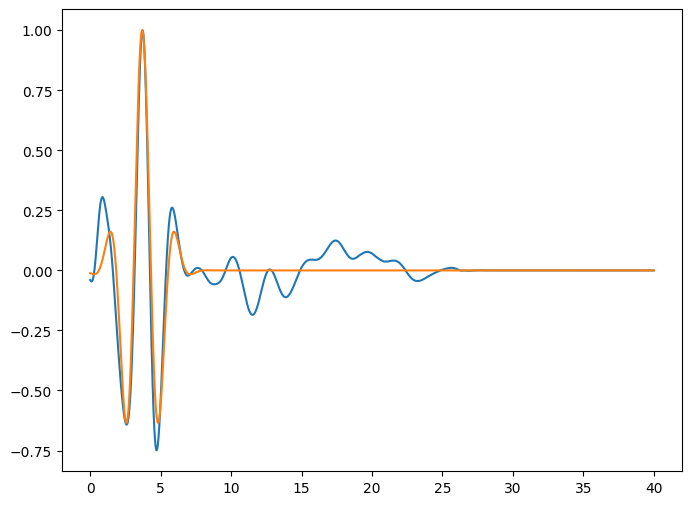

Estimated gather centroid frequency: 388.57 Hz, Wavelet length: 2.57 ms


Operator `Forward` ran in 4.66 s
Operator `Adjoint` ran in 4.63 s


Scale:  327747.88231109316 3.5955281447104834 4.509157458900108 33.03355168972701
Iter 0: Misfit = 1.3087e+05


Operator `Forward` ran in 4.65 s
Operator `Adjoint` ran in 4.64 s


Scale:  404400.9077981124 3.5955281447104834 3.33640130451553 4.598347385549494
Iter 1: Misfit = 2.4459e+04


...

Scale:  542519.2615081711 3.5955281447104834 4.095940594368418 23.18275000382089
Iter 2: Misfit = 1.8082e+04


Operator `Forward` ran in 4.66 s
Operator `Adjoint` ran in 4.63 s


Scale:  764140.2074873819 3.5955281447104834 4.277060175782391 4.481274671622394
Iter 3: Misfit = 2.7914e+03


Operator `Forward` ran in 4.65 s
Operator `Adjoint` ran in 4.62 s


Scale:  930626.4049710239 3.5955281447104834 4.436950399110017 6.411289076578278
Iter 4: Misfit = 1.7964e+03


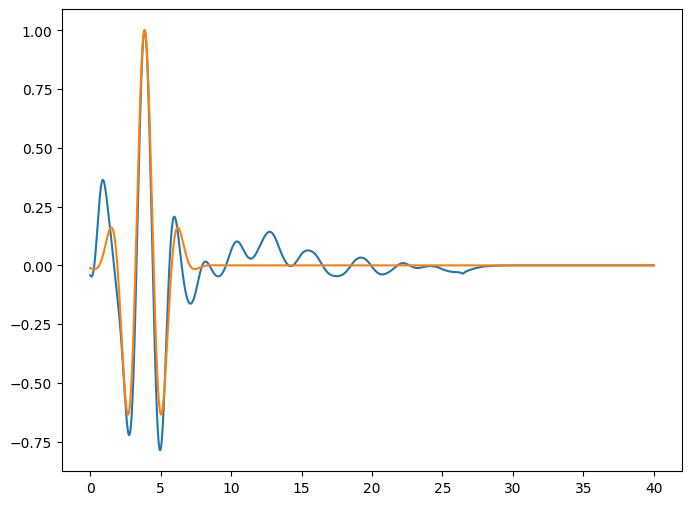

Estimated gather centroid frequency: 379.27 Hz, Wavelet length: 2.64 ms


Operator `Forward` ran in 4.66 s
Operator `Adjoint` ran in 4.63 s


Scale:  283607.37673011434 3.740748580895445 4.098038372962711 34.89267531670618
Iter 0: Misfit = 1.3753e+05


Operator `Forward` ran in 4.65 s
Operator `Adjoint` ran in 4.63 s


Scale:  375058.7739219322 3.740748580895445 3.1421331090306914 6.047596354573691
Iter 1: Misfit = 2.4485e+04


...

Scale:  488558.04701367754 3.740748580895445 3.8658431818122407 19.395380617500194
Iter 2: Misfit = 1.6897e+04


Operator `Forward` ran in 4.64 s
Operator `Adjoint` ran in 4.64 s


Scale:  523540.53463059844 3.740748580895445 3.1909943807350762 2.8229494874495407
Iter 3: Misfit = 4.2188e+03


Operator `Forward` ran in 4.65 s
Operator `Adjoint` ran in 4.63 s


Scale:  736714.4430219424 3.740748580895445 3.8806352886257622 10.803954181560673
Iter 4: Misfit = 3.2130e+03


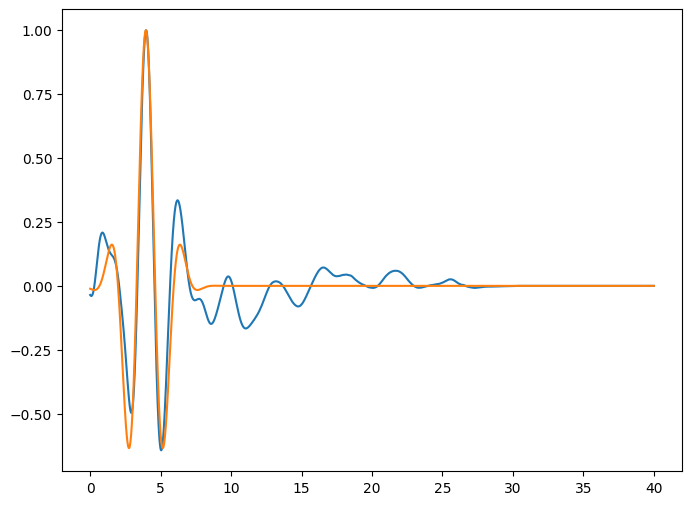

Estimated gather centroid frequency: 408.51 Hz, Wavelet length: 2.45 ms


Operator `Forward` ran in 4.72 s
Operator `Adjoint` ran in 4.64 s


Scale:  386515.95686303417 5.064850782970031 5.22568546934156 24.495493867691494
Iter 0: Misfit = 1.1564e+05


Operator `Forward` ran in 4.55 s
Operator `Adjoint` ran in 4.62 s


Scale:  572803.5934821495 5.064850782970031 3.849449763104183 5.258057118184111
Iter 1: Misfit = 1.4916e+04


...

Scale:  719482.6149893324 5.064850782970031 4.854473236633092 7.15627082187827
Iter 2: Misfit = 8.4628e+03


Operator `Forward` ran in 4.62 s
Operator `Adjoint` ran in 4.62 s


Scale:  768358.3474203561 5.064850782970031 3.806600920367907 2.7569294362085723
Iter 3: Misfit = 3.5373e+03


Operator `Forward` ran in 4.56 s
Operator `Adjoint` ran in 4.63 s


Scale:  1042633.3940452014 5.064850782970031 4.703416956967157 9.8492418508872
Iter 4: Misfit = 2.3369e+03


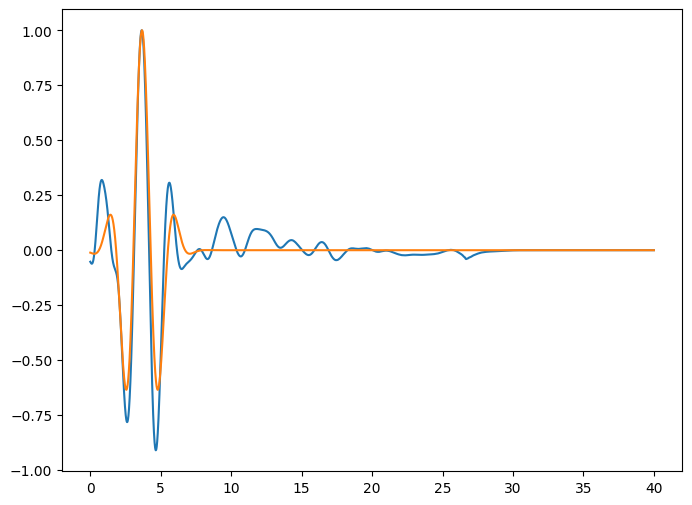

Estimated gather centroid frequency: 420.89 Hz, Wavelet length: 2.38 ms


Operator `Forward` ran in 4.69 s
Operator `Adjoint` ran in 4.63 s


Scale:  323259.85729515174 3.9958315213159974 4.081127679655669 32.050516460759084
Iter 0: Misfit = 1.1067e+05


Operator `Forward` ran in 4.62 s
Operator `Adjoint` ran in 4.60 s


Scale:  486713.74587960687 3.9958315213159974 2.8469429630969323 6.692770945141467
Iter 1: Misfit = 1.4733e+04


...

Scale:  597216.3665747271 3.9958315213159974 3.610729794309244 8.407066999025385
Iter 2: Misfit = 8.7181e+03


Operator `Forward` ran in 4.59 s
Operator `Adjoint` ran in 4.63 s


Scale:  636833.4167163926 3.9958315213159974 2.8895661727421267 3.7884270659239183
Iter 3: Misfit = 4.2380e+03


Operator `Forward` ran in 4.57 s
Operator `Adjoint` ran in 4.57 s


Scale:  834123.9651677132 3.9958315213159974 3.599147672998168 11.62306754100202
Iter 4: Misfit = 2.8643e+03


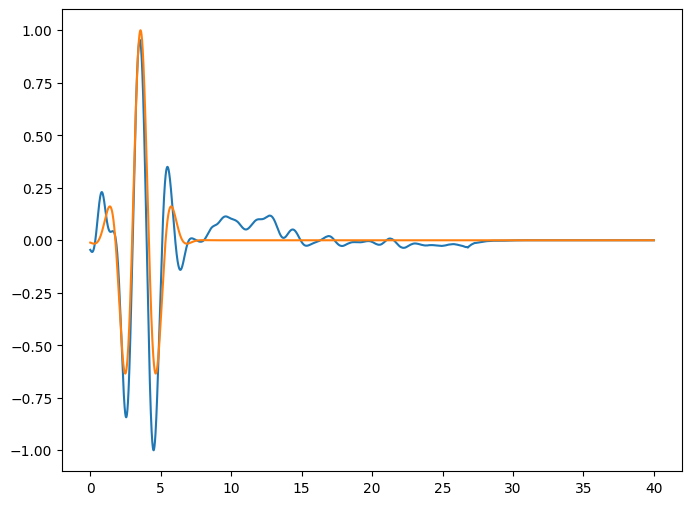

Estimated gather centroid frequency: 452.87 Hz, Wavelet length: 2.21 ms


Operator `Forward` ran in 4.74 s
Operator `Adjoint` ran in 4.62 s


Scale:  234967.39923674284 2.74356343447315 2.862538551133685 56.66481478803848
Iter 0: Misfit = 9.7651e+04


Operator `Forward` ran in 4.64 s
Operator `Adjoint` ran in 4.63 s


Scale:  356274.33618926426 2.74356343447315 1.9064133706252246 8.963228636007662
Iter 1: Misfit = 1.1926e+04


...

Scale:  437409.05150529573 2.74356343447315 2.569342637682718 14.440444678045528
Iter 2: Misfit = 7.8979e+03


Operator `Forward` ran in 4.64 s
Operator `Adjoint` ran in 4.64 s


Scale:  437666.76326399285 2.74356343447315 1.9580532213390562 5.029620038964552
Iter 3: Misfit = 3.9486e+03


Operator `Forward` ran in 4.61 s
Operator `Adjoint` ran in 4.65 s


Scale:  590810.8988544937 2.74356343447315 2.5440053636519773 25.989460477554804
Iter 4: Misfit = 2.9118e+03


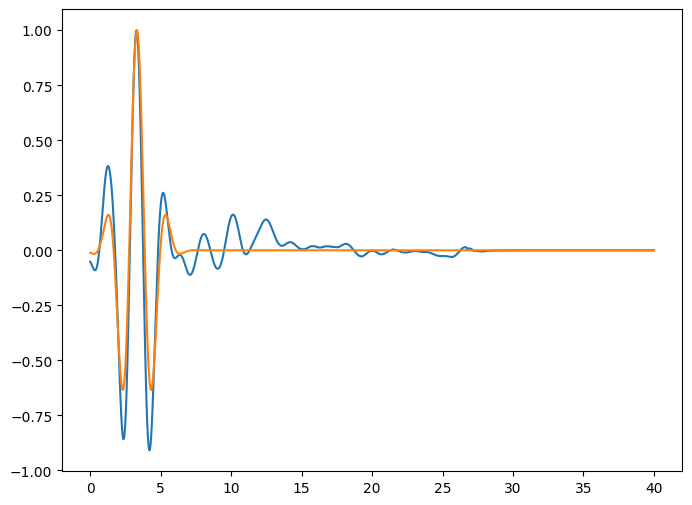

Estimated gather centroid frequency: 480.64 Hz, Wavelet length: 2.08 ms


Operator `Forward` ran in 4.73 s
Operator `Adjoint` ran in 4.64 s


Scale:  274702.6122730712 2.9713797794834713 3.2231147491207937 56.17105362371645
Iter 0: Misfit = 8.6769e+04


Operator `Forward` ran in 4.65 s
Operator `Adjoint` ran in 4.63 s


Scale:  401131.13267123944 2.9713797794834713 2.1525919132741707 7.801444607417896
Iter 1: Misfit = 1.2080e+04


...

Scale:  496929.13765931426 2.9713797794834713 2.966295256457803 16.652721484746834
Iter 2: Misfit = 8.6585e+03


Operator `Forward` ran in 4.63 s
Operator `Adjoint` ran in 4.64 s


Scale:  463476.63621381484 2.9713797794834713 2.164542832441622 4.057756055357733
Iter 3: Misfit = 4.1906e+03


Operator `Forward` ran in 4.64 s
Operator `Adjoint` ran in 4.60 s


Scale:  653691.86926217 2.9713797794834713 2.8573556354508263 23.739914859593956
Iter 4: Misfit = 3.3161e+03


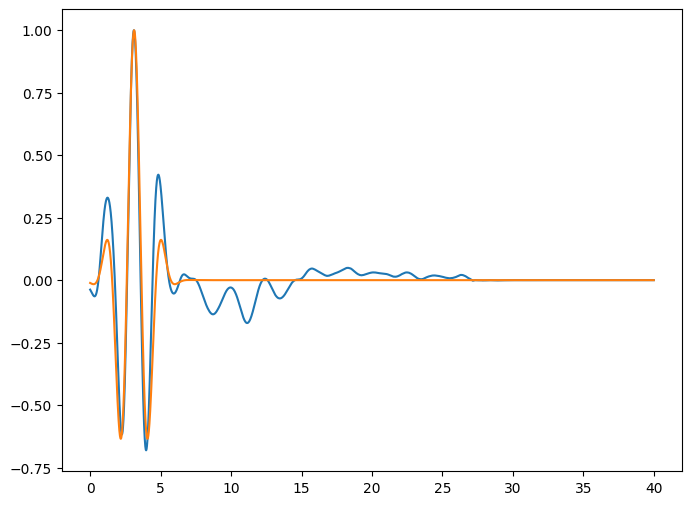

Estimated gather centroid frequency: 460.18 Hz, Wavelet length: 2.17 ms


Operator `Forward` ran in 4.73 s
Operator `Adjoint` ran in 4.58 s


Scale:  213915.5733402474 2.2770508468600883 2.515422481432815 82.05830022923807
Iter 0: Misfit = 9.5521e+04


Operator `Forward` ran in 4.64 s
Operator `Adjoint` ran in 4.58 s


Scale:  296004.0702633825 2.2770508468600883 1.705974024585589 9.100501097631414
Iter 1: Misfit = 1.2939e+04


...

Scale:  387896.2246510854 2.2770508468600883 2.2386960126604603 35.93102381034232
Iter 2: Misfit = 9.7786e+03


Operator `Forward` ran in 4.64 s
Operator `Adjoint` ran in 4.65 s


Scale:  362712.1641588114 2.2770508468600883 1.6508907905808783 4.739317814039103
Iter 3: Misfit = 3.0653e+03


Operator `Forward` ran in 4.65 s
Operator `Adjoint` ran in 4.57 s


Scale:  537672.144653192 2.2770508468600883 2.3153174460986037 16.34376806042799
Iter 4: Misfit = 2.4519e+03


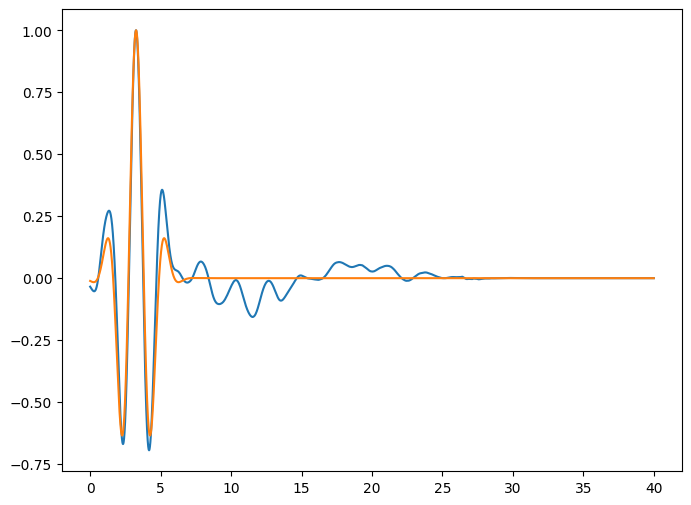

Estimated gather centroid frequency: 466.06 Hz, Wavelet length: 2.15 ms


Operator `Forward` ran in 4.73 s
Operator `Adjoint` ran in 4.63 s


Scale:  232997.71662957087 2.2294834203138993 2.4658594301588654 87.5277103570214
Iter 0: Misfit = 9.3333e+04


Operator `Forward` ran in 4.58 s
Operator `Adjoint` ran in 4.57 s


Scale:  291619.62183503906 2.2294834203138993 1.719255335741062 8.043757534888377
Iter 1: Misfit = 1.4809e+04


...

Scale:  401831.24295847013 2.2294834203138993 2.0627084277158185 47.14779825570231
Iter 2: Misfit = 1.1875e+04


Operator `Forward` ran in 4.64 s
Operator `Adjoint` ran in 4.64 s


Scale:  414237.85571052984 2.2294834203138993 1.9892776176233355 6.750244040828965
Iter 3: Misfit = 3.2058e+03


Operator `Forward` ran in 4.65 s
Operator `Adjoint` ran in 4.63 s


Scale:  587958.8922055467 2.2294834203138993 2.490592661393028 21.490453551529953
Iter 4: Misfit = 2.4942e+03


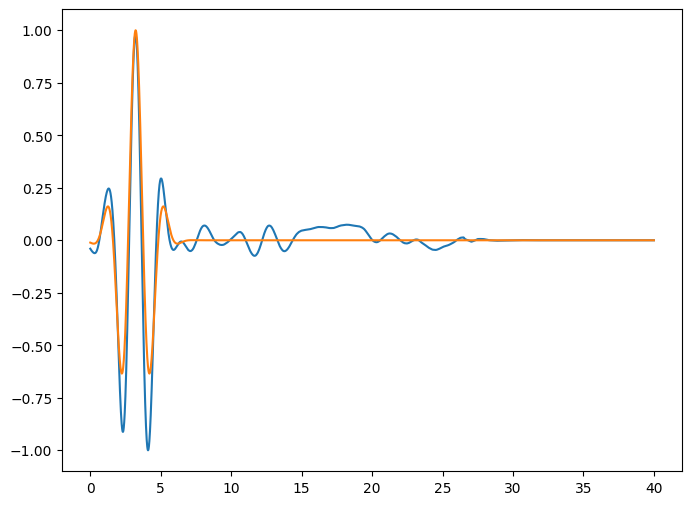

Estimated gather centroid frequency: 476.35 Hz, Wavelet length: 2.10 ms


Operator `Forward` ran in 4.71 s
Operator `Adjoint` ran in 4.65 s


Scale:  249440.81918858452 1.8697278989957324 2.2541956439170345 99.97521910156827
Iter 0: Misfit = 8.9622e+04


Operator `Forward` ran in 4.63 s
Operator `Adjoint` ran in 4.61 s


Scale:  261678.70285848688 1.8697278989957324 1.5881676574660797 7.274446487288638
Iter 1: Misfit = 1.6525e+04


...

Scale:  392987.12749903876 1.8697278989957324 1.794421902781401 26.334425859792482
Iter 2: Misfit = 1.3798e+04


Operator `Forward` ran in 4.55 s
Operator `Adjoint` ran in 4.63 s


Scale:  354021.7156341027 1.8697278989957324 1.9939417490011524 6.91173872225426
Iter 3: Misfit = 8.3258e+03


Operator `Forward` ran in 4.59 s
Operator `Adjoint` ran in 4.63 s


Scale:  484871.2539317494 1.8697278989957324 2.09069114070088 38.280927955229714
Iter 4: Misfit = 7.1330e+03


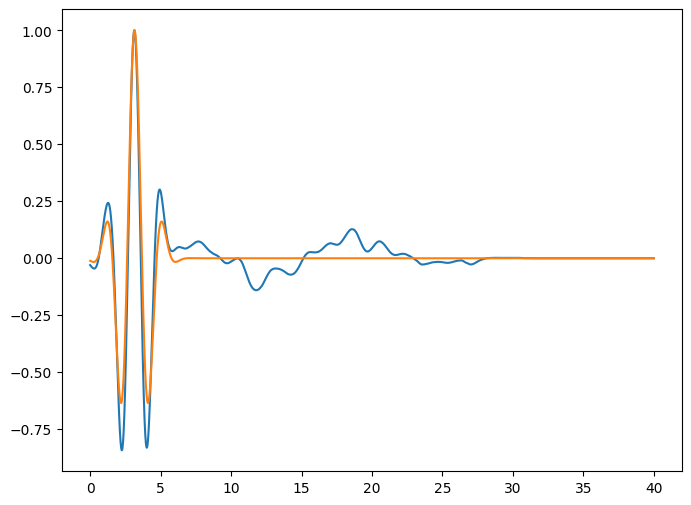

Estimated gather centroid frequency: 483.69 Hz, Wavelet length: 2.07 ms


Operator `Forward` ran in 4.70 s
Operator `Adjoint` ran in 4.63 s


Scale:  280600.4237982821 1.890816423123321 2.1501962327078377 102.63036745925925
Iter 0: Misfit = 8.7122e+04


Operator `Forward` ran in 4.57 s
Operator `Adjoint` ran in 4.62 s


Scale:  233424.53462047002 1.890816423123321 1.5821200090343295 6.898759566325735
Iter 1: Misfit = 2.1811e+04


...

Scale:  372691.2024970042 1.890816423123321 1.5695131669057918 13.334374297629308
Iter 2: Misfit = 1.8666e+04


Operator `Forward` ran in 4.63 s
Operator `Adjoint` ran in 4.63 s


Scale:  410468.89905333094 1.890816423123321 1.9217498897660295 11.694730542316833
Iter 3: Misfit = 1.5170e+04


Operator `Forward` ran in 4.67 s
Operator `Adjoint` ran in 4.65 s


Scale:  418503.3185502896 1.890816423123321 1.6513269759749096 9.598201030653904
Iter 4: Misfit = 1.2868e+04


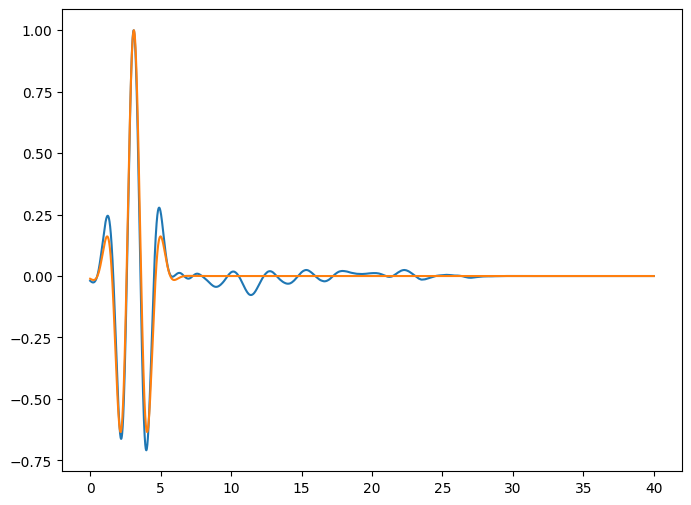

Estimated gather centroid frequency: 446.38 Hz, Wavelet length: 2.24 ms


Operator `Forward` ran in 4.71 s
Operator `Adjoint` ran in 4.63 s


Scale:  266810.57170052425 1.9827038983456993 2.1572155208049324 95.31310965159687
Iter 0: Misfit = 1.0241e+05


Operator `Forward` ran in 4.66 s
Operator `Adjoint` ran in 4.55 s


Scale:  205350.41244862287 1.9827038983456993 1.5562072232562774 7.350468190795742
Iter 1: Misfit = 3.4209e+04


...

Scale:  329017.58834483987 1.9827038983456993 1.489135362189803 13.796474478767061
Iter 2: Misfit = 2.9685e+04


Operator `Forward` ran in 4.66 s
Operator `Adjoint` ran in 4.61 s


Scale:  363586.1976259058 1.9827038983456993 1.9738264242401216 12.814100751075316
Iter 3: Misfit = 2.4826e+04


Operator `Forward` ran in 4.58 s
Operator `Adjoint` ran in 4.65 s


Scale:  365918.0566242642 1.9827038983456993 1.5983539364192747 10.100209172258477
Iter 4: Misfit = 2.1374e+04


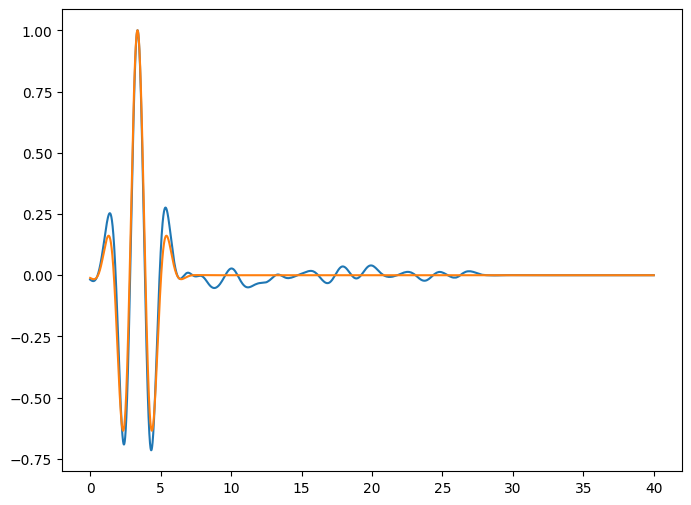

Estimated gather centroid frequency: 407.25 Hz, Wavelet length: 2.46 ms


Operator `Forward` ran in 4.77 s
Operator `Adjoint` ran in 4.65 s


Scale:  250372.57956868058 2.0031643912073513 2.5845894137321426 75.32313662328751
Iter 0: Misfit = 1.2257e+05


Operator `Forward` ran in 4.64 s
Operator `Adjoint` ran in 4.65 s


Scale:  222107.5310440041 2.0031643912073513 1.7736740091789125 7.296339595598885
Iter 1: Misfit = 3.8327e+04


...

Scale:  338616.5897465811 2.0031643912073513 1.9100870331255408 22.816117791215074
Iter 2: Misfit = 3.2528e+04


Operator `Forward` ran in 4.64 s
Operator `Adjoint` ran in 4.63 s


Scale:  318290.9657567561 2.0031643912073513 2.4087604610200852 7.591558142045517
Iter 3: Misfit = 2.2261e+04


Operator `Forward` ran in 4.67 s
Operator `Adjoint` ran in 4.65 s


Scale:  413038.62398267834 2.0031643912073513 2.3943731052797323 40.17639629587157
Iter 4: Misfit = 1.9323e+04


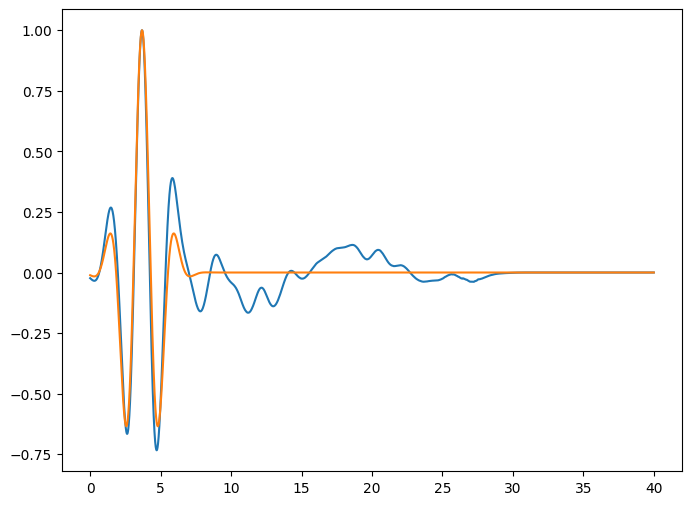

Estimated gather centroid frequency: 451.89 Hz, Wavelet length: 2.21 ms


Operator `Forward` ran in 4.74 s
Operator `Adjoint` ran in 4.63 s


Scale:  307777.85090821196 3.123848464575876 3.594590901721541 51.42184547239134
Iter 0: Misfit = 9.8011e+04


Operator `Forward` ran in 4.64 s
Operator `Adjoint` ran in 4.63 s


Scale:  373587.84622309037 3.123848464575876 2.4829369339086105 5.322289950105746
Iter 1: Misfit = 1.5233e+04


...

Scale:  525057.6060242448 3.123848464575876 3.080983959768627 25.769243408581968
Iter 2: Misfit = 1.1837e+04


Operator `Forward` ran in 4.62 s
Operator `Adjoint` ran in 4.62 s


Scale:  533412.372743807 3.123848464575876 2.58605528807771 4.206471062070049
Iter 3: Misfit = 3.2978e+03


Operator `Forward` ran in 4.62 s
Operator `Adjoint` ran in 4.63 s


Scale:  757322.9005069212 3.123848464575876 3.584365182504398 12.024210038065775
Iter 4: Misfit = 2.5109e+03


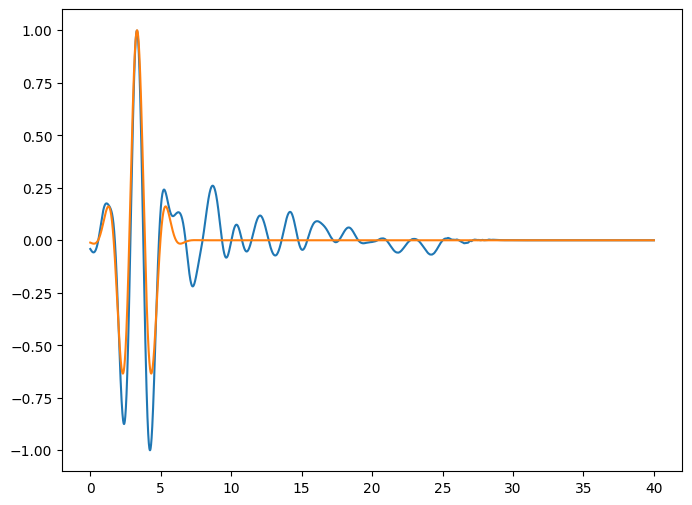

Estimated gather centroid frequency: 438.36 Hz, Wavelet length: 2.28 ms


Operator `Forward` ran in 4.73 s
Operator `Adjoint` ran in 4.64 s


Scale:  211038.45044230833 2.5282951715546016 2.6927816506771474 49.939801382847165
Iter 0: Misfit = 1.0418e+05


Operator `Forward` ran in 4.63 s
Operator `Adjoint` ran in 4.64 s


Scale:  302022.17428551323 2.5282951715546016 2.033756944914812 10.746750810310486
Iter 1: Misfit = 1.8219e+04


...

Scale:  341453.3127236559 2.5282951715546016 2.4613759657197334 9.640959209948672
Iter 2: Misfit = 1.2014e+04


Operator `Forward` ran in 4.64 s
Operator `Adjoint` ran in 4.63 s


Scale:  375748.8522942115 2.5282951715546016 2.0580736261631745 8.647605168958652
Iter 3: Misfit = 8.1491e+03


Operator `Forward` ran in 4.62 s
Operator `Adjoint` ran in 4.60 s


Scale:  412572.0273702962 2.5282951715546016 2.468525730244421 7.5154358037996545
Iter 4: Misfit = 5.5639e+03


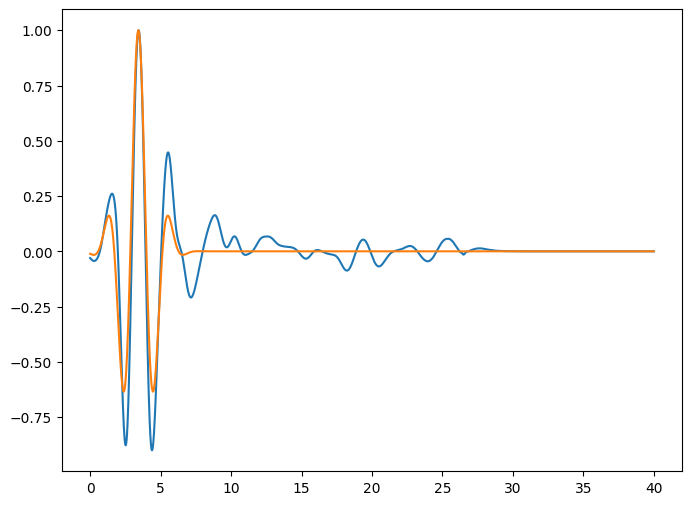

Estimated gather centroid frequency: 467.40 Hz, Wavelet length: 2.14 ms


Operator `Forward` ran in 4.73 s
Operator `Adjoint` ran in 4.56 s


Scale:  255446.71817855822 3.1652772360365087 2.326340625197284 34.60917957370458
Iter 0: Misfit = 9.0712e+04


Operator `Forward` ran in 4.64 s
Operator `Adjoint` ran in 4.65 s


Scale:  368221.5839156114 3.1652772360365087 2.1102055134969304 11.738686682756782
Iter 1: Misfit = 1.9493e+04


...

Scale:  372589.03604326 3.1652772360365087 2.0483181633857304 4.986971649441445
Iter 2: Misfit = 1.1217e+04


Operator `Forward` ran in 4.65 s
Operator `Adjoint` ran in 4.63 s


Scale:  481205.7927979857 3.1652772360365087 1.9676784764929667 21.429900047582176
Iter 3: Misfit = 8.6704e+03


Operator `Forward` ran in 4.64 s
Operator `Adjoint` ran in 4.62 s


Scale:  482750.5815743036 3.1652772360365087 2.313262537659079 2.4367014206761586
Iter 4: Misfit = 2.3688e+03


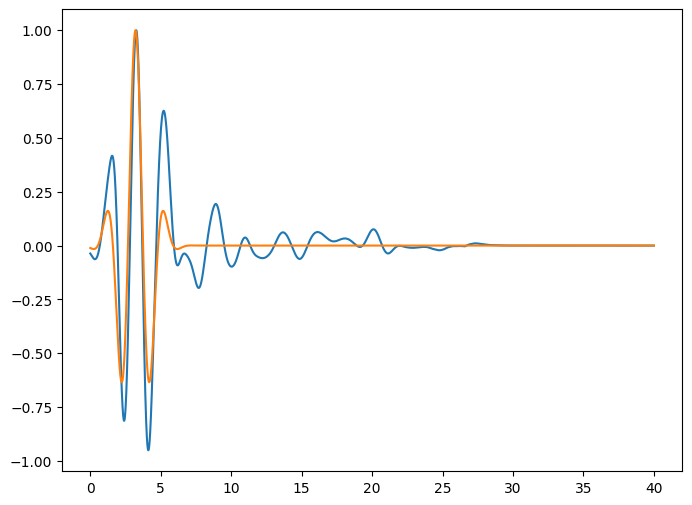

Estimated gather centroid frequency: 441.86 Hz, Wavelet length: 2.26 ms


Operator `Forward` ran in 4.70 s
Operator `Adjoint` ran in 4.66 s


Scale:  329335.54236710246 4.176801786710329 3.1602401906531035 28.986665783287386
Iter 0: Misfit = 1.0064e+05


Operator `Forward` ran in 4.58 s
Operator `Adjoint` ran in 4.61 s


Scale:  457968.57841835555 4.176801786710329 2.855768344075103 6.0905540311034185
Iter 1: Misfit = 2.0936e+04


...

Scale:  519640.3532195032 4.176801786710329 2.8107231414096887 6.051171564962724
Iter 2: Misfit = 1.4639e+04


Operator `Forward` ran in 4.64 s
Operator `Adjoint` ran in 4.63 s


Scale:  554086.4215371066 4.176801786710329 2.750385609585608 4.61351126802024
Iter 3: Misfit = 1.0188e+04


Operator `Forward` ran in 4.62 s
Operator `Adjoint` ran in 4.61 s


Scale:  629374.6105695704 4.176801786710329 3.033540948478692 5.772868128643091
Iter 4: Misfit = 7.5300e+03


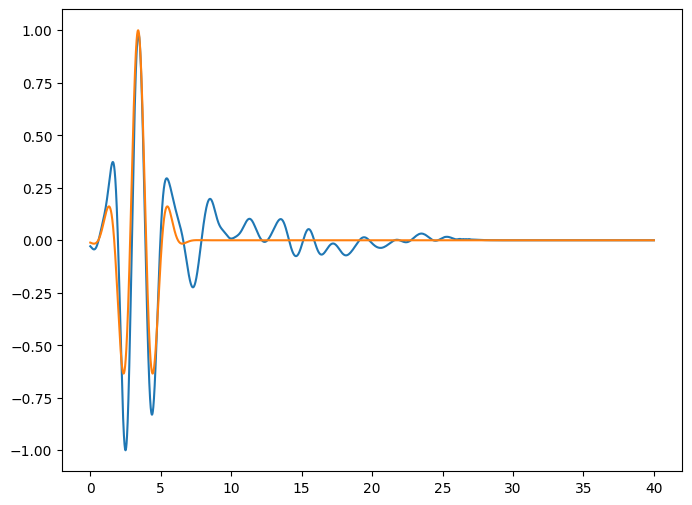

Estimated gather centroid frequency: 456.52 Hz, Wavelet length: 2.19 ms


Operator `Forward` ran in 4.73 s
Operator `Adjoint` ran in 4.62 s


Scale:  299836.12848854717 3.104417886734979 2.940822187414282 38.40957479625829
Iter 0: Misfit = 9.5658e+04


Operator `Forward` ran in 4.63 s
Operator `Adjoint` ran in 4.63 s


Scale:  360869.835565234 3.104417886734979 2.7329095849663814 5.3512143183889975
Iter 1: Misfit = 2.3073e+04


...

Scale:  455354.201331538 3.104417886734979 2.702187583777499 17.217652859142373
Iter 2: Misfit = 1.8506e+04


Operator `Forward` ran in 4.55 s
Operator `Adjoint` ran in 4.64 s


Scale:  370350.8601340192 3.104417886734979 2.3384381362637496 2.819893060298015
Iter 3: Misfit = 9.2218e+03


Operator `Forward` ran in 4.66 s
Operator `Adjoint` ran in 4.64 s


Scale:  543873.1531594542 3.104417886734979 2.7285627199250273 8.865551555792438
Iter 4: Misfit = 7.8940e+03


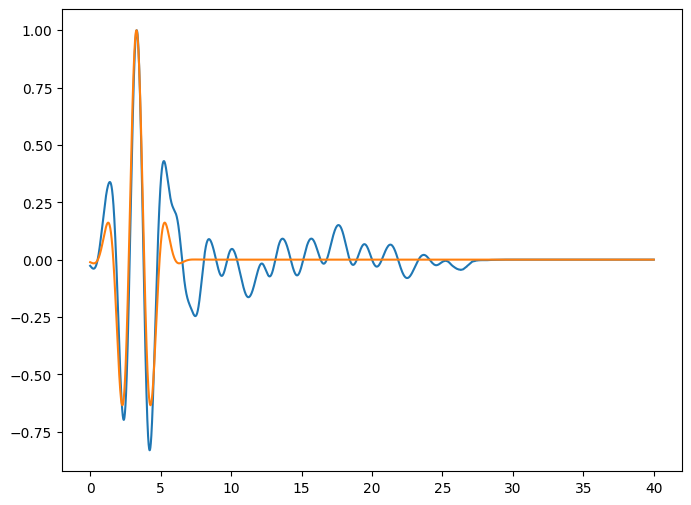

Estimated gather centroid frequency: 457.08 Hz, Wavelet length: 2.19 ms


Operator `Forward` ran in 4.68 s
Operator `Adjoint` ran in 4.62 s


Scale:  316820.8475185598 2.994699151269078 2.9958239465624534 47.94912940514532
Iter 0: Misfit = 9.6339e+04


Operator `Forward` ran in 4.57 s
Operator `Adjoint` ran in 4.58 s


Scale:  290128.9752139414 2.994699151269078 2.4425986408745644 3.7129966684015296
Iter 1: Misfit = 2.7619e+04


...

Scale:  428690.715441845 2.994699151269078 2.3258096847502987 11.389145303563765
Iter 2: Misfit = 2.4130e+04


Operator `Forward` ran in 4.67 s
Operator `Adjoint` ran in 4.62 s


Scale:  401828.2897278776 2.994699151269078 2.7575135473944763 3.952147106886458
Iter 3: Misfit = 1.7409e+04


Operator `Forward` ran in 4.65 s
Operator `Adjoint` ran in 4.63 s


Scale:  515380.97675307613 2.994699151269078 2.8408394301039874 34.054802433561
Iter 4: Misfit = 1.5483e+04


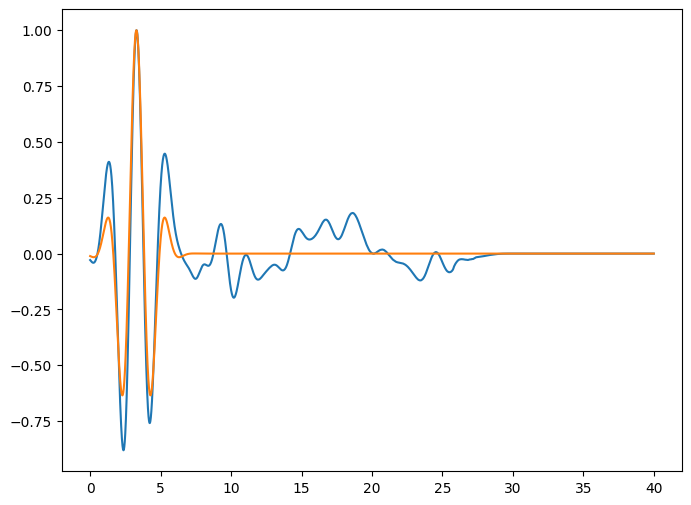

Estimated gather centroid frequency: 455.20 Hz, Wavelet length: 2.20 ms


Operator `Forward` ran in 4.74 s
Operator `Adjoint` ran in 4.64 s


Scale:  341667.57320135494 2.891311099817207 3.279212068960489 42.81812187366542
Iter 0: Misfit = 9.6842e+04


Operator `Forward` ran in 4.64 s
Operator `Adjoint` ran in 4.62 s


Scale:  305855.9414891923 2.891311099817207 2.7849192213761524 3.3739674202505365
Iter 1: Misfit = 2.7727e+04


...

Scale:  459109.79386655986 2.891311099817207 2.6217023627069853 9.749943556292564
Iter 2: Misfit = 2.4194e+04


Operator `Forward` ran in 4.62 s
Operator `Adjoint` ran in 4.58 s


Scale:  435920.36869572016 2.891311099817207 2.8947712480291776 3.684975978309642
Iter 3: Misfit = 1.7701e+04


Operator `Forward` ran in 4.61 s
Operator `Adjoint` ran in 4.64 s


Scale:  555591.613302329 2.891311099817207 3.0708967033910066 27.04855124924471
Iter 4: Misfit = 1.5673e+04


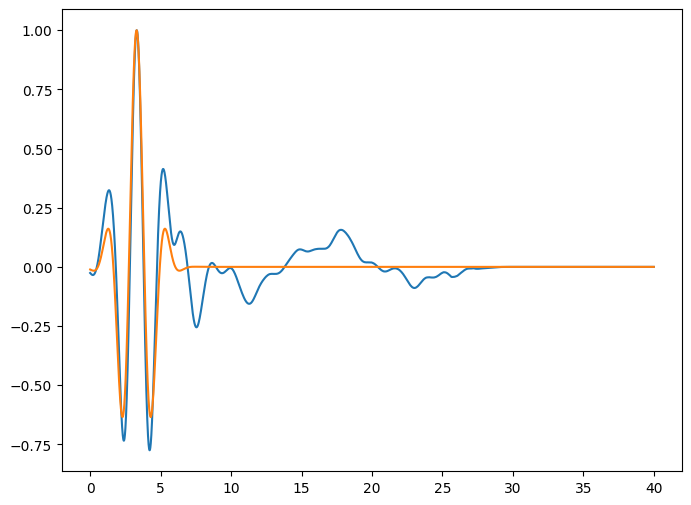

Estimated gather centroid frequency: 455.48 Hz, Wavelet length: 2.20 ms


Operator `Forward` ran in 4.71 s
Operator `Adjoint` ran in 4.58 s


Scale:  540027.9444293553 4.555717865633462 5.253488052824441 24.459829077905052
Iter 0: Misfit = 9.4224e+04


Operator `Forward` ran in 4.65 s
Operator `Adjoint` ran in 4.61 s


Scale:  549523.0338695998 4.555717865633462 4.746451885177565 1.765149271472882
Iter 1: Misfit = 2.2257e+04


...

Scale:  771876.8653529973 4.555717865633462 4.1805655006276 5.7485877328099555
Iter 2: Misfit = 1.9446e+04


Operator `Forward` ran in 4.65 s
Operator `Adjoint` ran in 4.59 s


Scale:  735783.5515003136 4.555717865633462 4.937910645082728 1.7804303791744094
Iter 3: Misfit = 1.3246e+04


Operator `Forward` ran in 4.64 s
Operator `Adjoint` ran in 4.65 s


Scale:  941460.7967074221 4.555717865633462 5.214108386776599 16.471695308529604
Iter 4: Misfit = 1.1650e+04


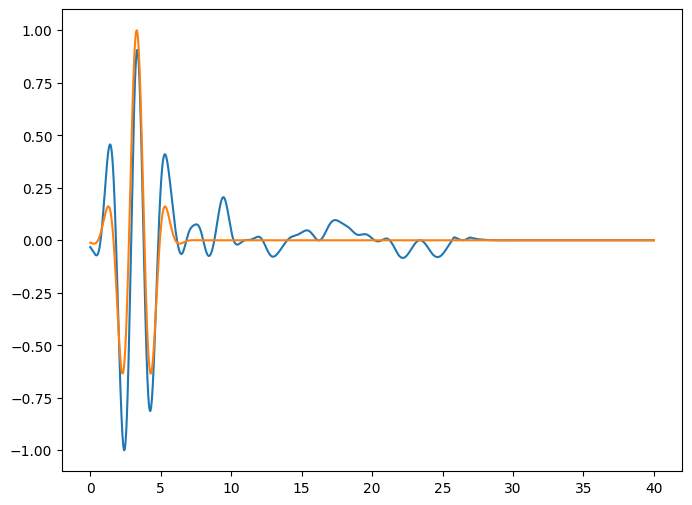

Estimated gather centroid frequency: 480.44 Hz, Wavelet length: 2.08 ms


Operator `Forward` ran in 4.72 s
Operator `Adjoint` ran in 4.64 s


Scale:  628906.9970709762 6.316714050164874 6.08193766482029 17.686484483623083
Iter 0: Misfit = 8.4070e+04


Operator `Forward` ran in 4.59 s
Operator `Adjoint` ran in 4.64 s


Scale:  705641.4235811349 6.316714050164874 5.13834435755064 1.6924124018307536
Iter 1: Misfit = 2.7440e+04


...

Scale:  884165.8940011071 6.316714050164874 5.4914560850433585 11.793052387497942
Iter 2: Misfit = 2.4350e+04


Operator `Forward` ran in 4.65 s
Operator `Adjoint` ran in 4.64 s


Scale:  855760.5361942919 6.316714050164874 6.676064858988705 1.2399065150843334
Iter 3: Misfit = 1.0693e+04


Operator `Forward` ran in 4.66 s
Operator `Adjoint` ran in 4.66 s


Scale:  1069462.8380096343 6.316714050164874 7.094183123798584 3.953387550105923
Iter 4: Misfit = 9.6901e+03


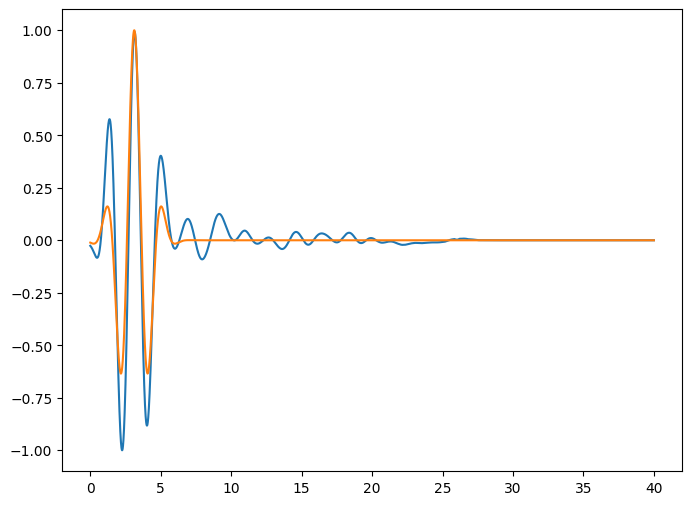

Estimated gather centroid frequency: 420.04 Hz, Wavelet length: 2.38 ms


Operator `Forward` ran in 4.72 s
Operator `Adjoint` ran in 4.64 s


Scale:  454638.80430286453 5.658276674873913 5.060449348398384 16.84009892412183
Iter 0: Misfit = 1.0948e+05


Operator `Forward` ran in 4.65 s
Operator `Adjoint` ran in 4.55 s


Scale:  551157.8367114284 5.658276674873913 4.099275895189402 3.474358866907692
Iter 1: Misfit = 3.4691e+04


...

Scale:  659834.8276380714 5.658276674873913 4.5141844778 7.345628748054079
Iter 2: Misfit = 2.7053e+04


Operator `Forward` ran in 4.61 s
Operator `Adjoint` ran in 4.56 s


Scale:  618953.9434840748 5.658276674873913 4.195289636903594 1.855537025877114
Iter 3: Misfit = 1.5917e+04


Operator `Forward` ran in 4.62 s
Operator `Adjoint` ran in 4.63 s


Scale:  807116.9731253884 5.658276674873913 4.906864745104282 11.851684639515371
Iter 4: Misfit = 1.3639e+04


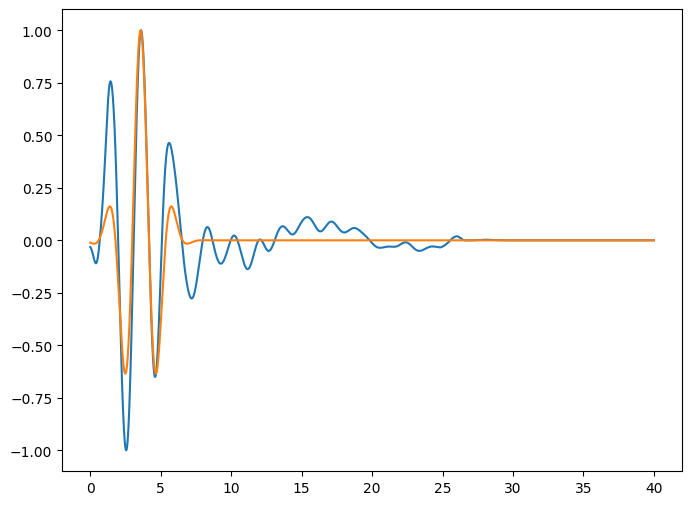

Estimated gather centroid frequency: 426.83 Hz, Wavelet length: 2.34 ms


Operator `Forward` ran in 4.71 s
Operator `Adjoint` ran in 4.64 s


Scale:  452251.4255186545 4.886146313180535 5.97225111561553 17.754791076892044
Iter 0: Misfit = 1.0622e+05


Operator `Forward` ran in 4.64 s
Operator `Adjoint` ran in 4.63 s


Scale:  554606.0076748352 4.886146313180535 4.406014400801192 3.566947893322069
Iter 1: Misfit = 3.2701e+04


...

Scale:  668162.6015616987 4.886146313180535 5.0928522523737065 8.147530933909078
Iter 2: Misfit = 2.5458e+04


Operator `Forward` ran in 4.65 s
Operator `Adjoint` ran in 4.64 s


Scale:  623986.8755633051 4.886146313180535 4.181757761819372 1.843968775011462
Iter 3: Misfit = 1.4235e+04


Operator `Forward` ran in 4.62 s
Operator `Adjoint` ran in 4.62 s


Scale:  822967.0327154808 4.886146313180535 5.259436491553622 10.708988874839159
Iter 4: Misfit = 1.2194e+04


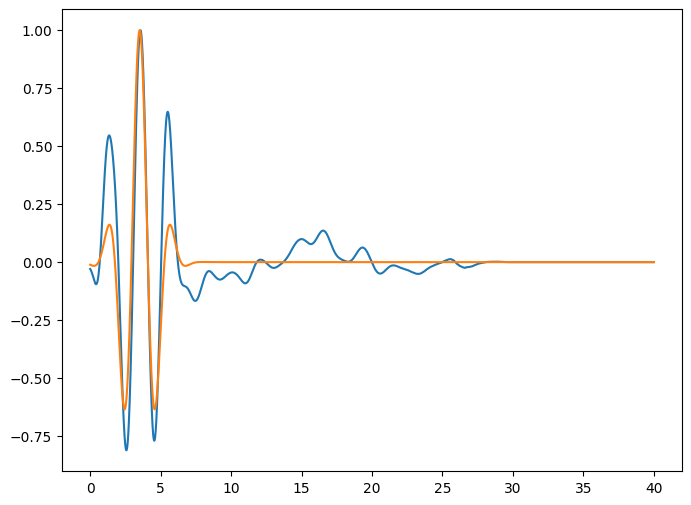

Estimated gather centroid frequency: 389.53 Hz, Wavelet length: 2.57 ms


Operator `Forward` ran in 4.74 s
Operator `Adjoint` ran in 4.64 s


Scale:  334813.783214568 4.743231879671382 6.116038230342559 23.40568411993861
Iter 0: Misfit = 1.2874e+05


Operator `Forward` ran in 4.65 s
Operator `Adjoint` ran in 4.61 s


Scale:  420087.1274191323 4.743231879671382 4.351157229075812 5.12748915396014
Iter 1: Misfit = 3.3033e+04


...

Scale:  516925.03108891076 4.743231879671382 5.2534923195906655 10.668655124132743
Iter 2: Misfit = 2.3767e+04


Operator `Forward` ran in 4.60 s
Operator `Adjoint` ran in 4.58 s


Scale:  507257.66767930245 4.743231879671382 4.25303260028479 2.7138070762119515
Iter 3: Misfit = 1.1635e+04


Operator `Forward` ran in 4.66 s
Operator `Adjoint` ran in 4.63 s


Scale:  674433.2124730618 4.743231879671382 5.248297266643214 16.593346935018538
Iter 4: Misfit = 9.3620e+03


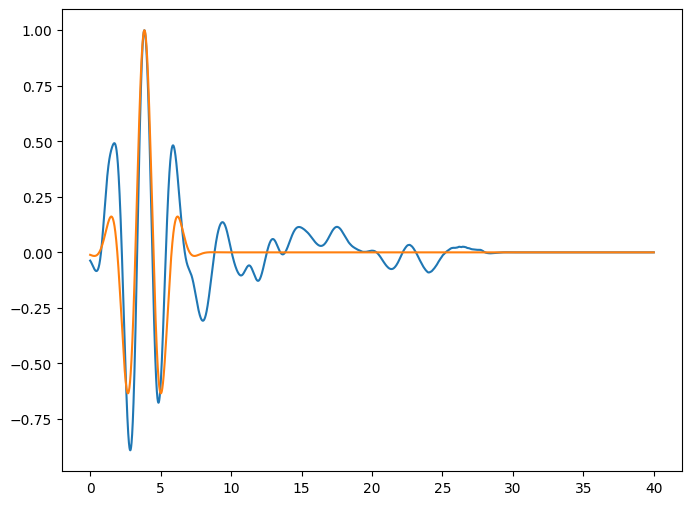

Estimated gather centroid frequency: 400.71 Hz, Wavelet length: 2.50 ms


Operator `Forward` ran in 4.73 s
Operator `Adjoint` ran in 4.57 s


Scale:  404525.60769152624 5.237328398918543 6.146202161237977 25.397631373099006
Iter 0: Misfit = 1.2114e+05


Operator `Forward` ran in 4.62 s
Operator `Adjoint` ran in 4.63 s


Scale:  500163.60202219506 5.237328398918543 4.50973622080999 3.7573074180445305
Iter 1: Misfit = 2.1555e+04


...

Scale:  680123.4141596003 5.237328398918543 5.34933212818859 15.547432638659217
Iter 2: Misfit = 1.5555e+04


Operator `Forward` ran in 4.63 s
Operator `Adjoint` ran in 4.64 s


Scale:  835021.6562298604 5.237328398918543 4.826064276937546 2.626361298410858
Iter 3: Misfit = 3.1202e+03


Operator `Forward` ran in 4.65 s
Operator `Adjoint` ran in 4.63 s


Scale:  1089561.03491588 5.237328398918543 6.038183311613383 7.616344653371023
Iter 4: Misfit = 2.2128e+03


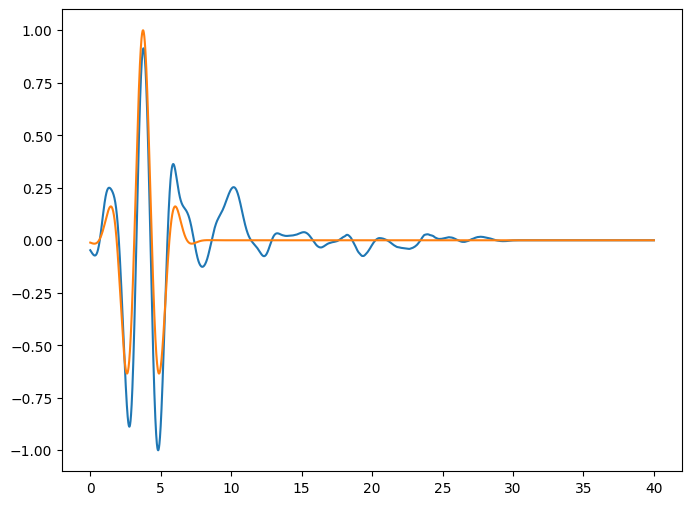

Estimated gather centroid frequency: 402.34 Hz, Wavelet length: 2.49 ms


Operator `Forward` ran in 4.72 s
Operator `Adjoint` ran in 4.62 s


Scale:  200350.23769792495 2.5317526735364213 2.4274318395066015 62.302553378293105
Iter 0: Misfit = 1.2457e+05


Operator `Forward` ran in 4.63 s
Operator `Adjoint` ran in 4.63 s


Scale:  227543.3357023914 2.5317526735364213 2.001012730273305 9.011967381389836
Iter 1: Misfit = 2.4439e+04


...

Scale:  327361.21280830714 2.5317526735364213 2.030018208700279 38.68223631709481
Iter 2: Misfit = 1.7863e+04


Operator `Forward` ran in 4.65 s
Operator `Adjoint` ran in 4.65 s


Scale:  391465.42199950595 2.5317526735364213 2.098164469209702 8.915639034407999
Iter 3: Misfit = 4.1880e+03


Operator `Forward` ran in 4.65 s
Operator `Adjoint` ran in 4.66 s


Scale:  517222.3329013274 2.5317526735364213 2.3260354854111926 15.082689461300694
Iter 4: Misfit = 2.7340e+03


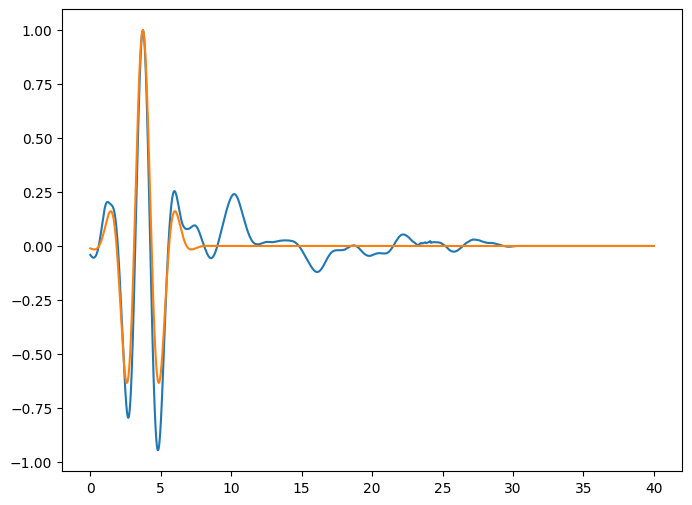

In [15]:
max_iter = 5
beta = 0.001

for k in range(31, len(dataset)):
    d_obs, sx, sz, rec_x, rec_z = dataset[k]
    f0 = estimate_centroid_frequency_gather(d_obs.T, model.critical_dt) / 1e3
    print(f"Estimated gather centroid frequency: {f0*1e3:.2f} Hz, Wavelet length: {1/f0:.2f} ms")
    src_pos = np.array([sx, sz])[None, :]
    rec_pos = np.vstack([rec_x, rec_z]).T
    geometry = AcquisitionGeometry(
        model, rec_pos, src_pos,
        t0, tn, f0=f0 * 2, src_type='Gabor'
    )
    current_wavelet = geometry.src.data[:].reshape(-1)
    initial_wavelet = np.copy(current_wavelet)
    scale_factor = 1.
    for i in range(max_iter):
        # Forward modeling
        geometry = AcquisitionGeometry(
            model, rec_pos, src_pos,
            t0, tn, f0=0.25, src_type=None, wav_data=current_wavelet
        )
        solver = AcousticWaveSolver(model, geometry, space_order=SO)
        d_syn = Receiver(name='d_syn', grid=model.grid, time_range=geometry.time_axis,
                        coordinates=geometry.rec_positions)
        solver.forward(vp=model.vp, rec=d_syn, save=False)
        residual = Receiver(name='residual', grid=model.grid, time_range=geometry.time_axis,
                    coordinates=geometry.rec_positions)
        # if i == 0:
        scale_factor = np.linalg.norm(d_obs.ravel())/np.linalg.norm(np.array(d_syn.data[:]).ravel())
        
        residual.data[:] = scale_factor*d_syn.data - d_obs.T
        
        # Compute gradient (adjoint source)
        srca, _, _ = solver.adjoint(vp=model.vp, rec=residual)
        gradient = srca.data
        gradient_tapered, window = left_taper_tukey(gradient.reshape(-1), alpha=0.05)
        gradient_tapered += beta*(current_wavelet - initial_wavelet)
        misfit = geometry.src.data.reshape(-1) - gradient_tapered.reshape(-1)
        alpha = 0.5*calculate_step_size(misfit, gradient)
        print("Scale: ", scale_factor, np.quantile(d_obs, 0.99), scale_factor*np.quantile(np.array(d_syn.data[:]), 0.99), alpha)
        current_wavelet = current_wavelet - alpha * gradient_tapered
        print(f"Iter {i}: Misfit = {np.dot(misfit.reshape(-1), misfit.reshape(-1))**2:.4e}")
    plt.plot(geometry.time_axis.time_values, current_wavelet/np.max(np.abs(current_wavelet)))
    plt.plot(geometry.time_axis.time_values, initial_wavelet/np.max(np.abs(initial_wavelet)))
    plt.show()
    np.save(f"wavelet_{k}_norm.npy", current_wavelet)
    np.save(f"wavelet_scale_{k}.npy", scale_factor)

In [11]:
d_syn.data[:].min()

Data(-1.6923479e-05, dtype=float32)

Operator `Forward` ran in 4.04 s


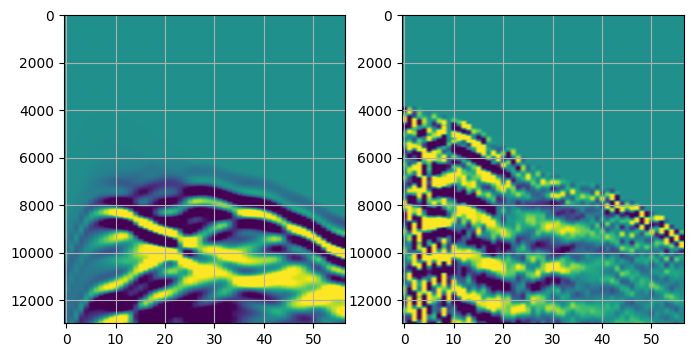

Operator `Forward` ran in 4.04 s


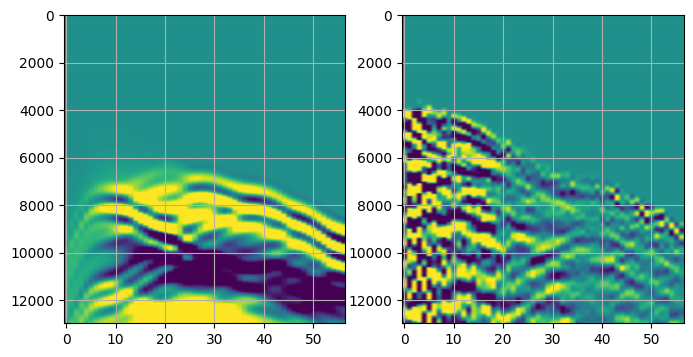

Operator `Forward` ran in 4.04 s


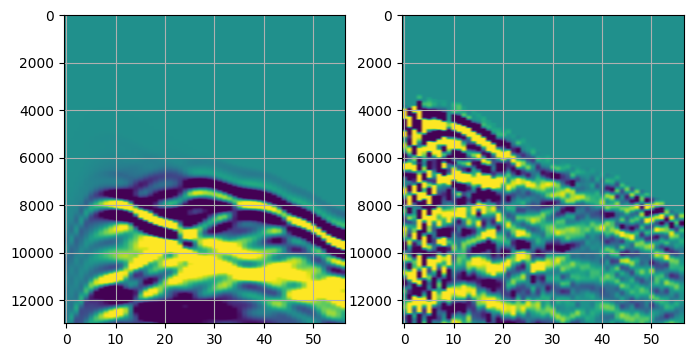

Operator `Forward` ran in 4.04 s


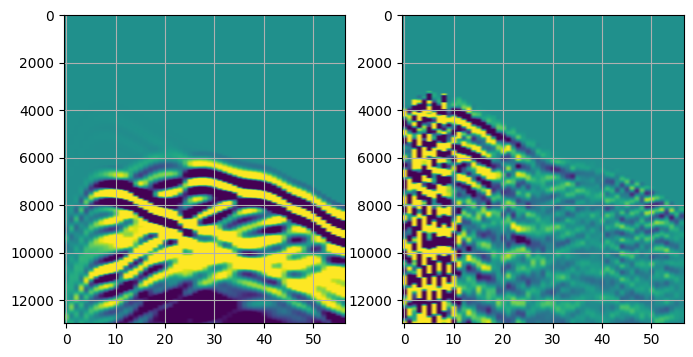

In [ ]:
N = 40
t0 = 0
tn = TMAX
for i in range(len(dataset)):
    d_obs, sx, sz, rec_x, rec_z = dataset[i]
    wav_data = np.load(f"Mex_wavelet_{i}_norm.npy")
    src_pos = np.array([sx, sz])[None, :]
    rec_pos = np.vstack([rec_x, rec_z]).T
    geometry = AcquisitionGeometry(
        model, rec_pos, src_pos,
        t0, tn, f0=0.25, src_type=None, wav_data=wav_data
    )
    solver = AcousticWaveSolver(model, geometry, space_order=SO)
    d_syn = Receiver(name='d_syn', grid=model.grid, time_range=geometry.time_axis,
                        coordinates=geometry.rec_positions)
    solver.forward(vp=model.vp, save=False, rec=d_syn)
    scale_factor = np.linalg.norm(d_obs.ravel())/np.linalg.norm(np.array(d_syn.data[:]).ravel())
    np.save(f"Mex_wavelet_{i}_norm_scalar.npy", scale_factor)
    
    fig, axs = plt.subplots(1, 2, figsize=(8, 4))
    qa = np.quantile(d_obs, 0.95)
    axs[0].imshow(scale_factor*d_syn.data[:], aspect='auto', vmin=-qa, vmax=qa)
    axs[0].grid()
    axs[1].imshow(d_obs.T, aspect='auto', vmin=-qa, vmax=qa)
    axs[1].grid()
    plt.show()
# srca, v, summary = solver.adjoint(vp=model.vp, rec=residual)

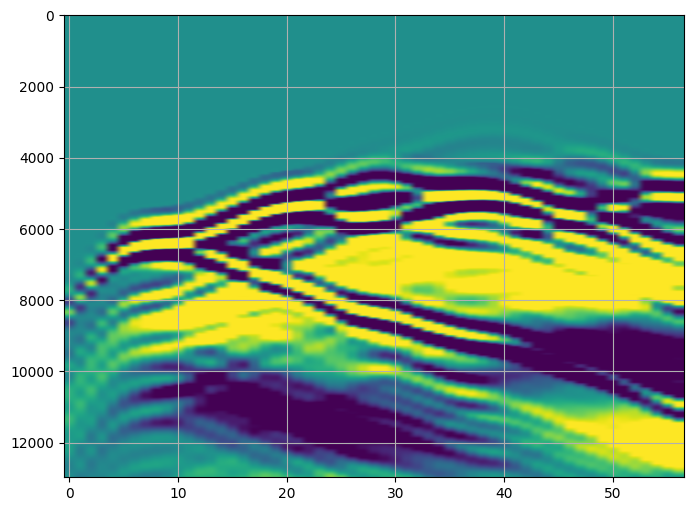

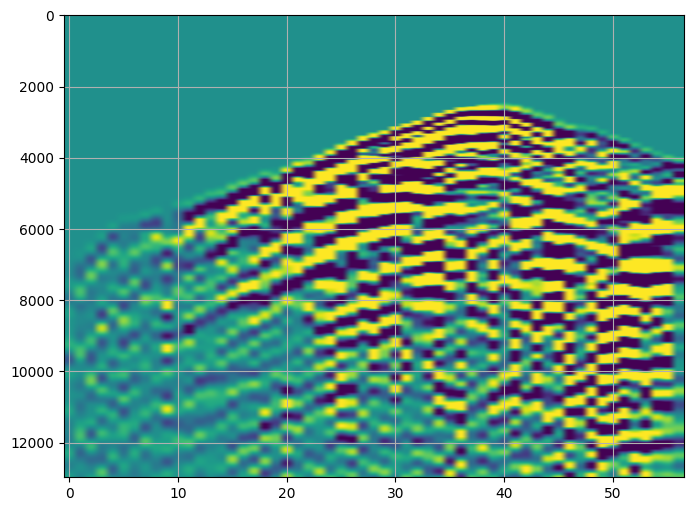

In [12]:
from matplotlib import pyplot as plt
# d_obs, sx, sz, rec_x, rec_z = dataset[20]
qa = np.quantile(d_obs, 0.9)
# qa = np.quantile(np.array(d_syn.data[:]).ravel(), 0.99)
plt.imshow(d_syn.data[:], aspect='auto', vmin=-qa, vmax=qa)
plt.grid()
plt.show()
plt.imshow(d_obs.T, aspect='auto', vmin=-qa, vmax=qa)
plt.grid()
plt.show()